<a href="https://colab.research.google.com/github/deepikadudigam/AI-Powered-Workforce-Analytics-Talent-Intelligence-Dashboard-Group-1/blob/main/Python_task.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Generate Python code for an AI-Powered Workforce Analytics and Talent Intelligence Dashboard to analyze employee workforce data. Create a sample employee dataset containing Employee ID, Department, Age, Years at Company, Monthly Income, Job Satisfaction, Performance Rating, Training Hours, and Attrition Status. Perform basic exploratory data analysis, calculate department-wise attrition rates, visualize attrition distribution and average job satisfaction by department, and build a Random Forest classification model to predict employee attrition risk. Display the model accuracy and feature importance.

In [1]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:

np.random.seed(42)

departments = ["IT", "HR", "Finance", "Sales", "Operations"]

data = {
    "Employee_ID": range(1001, 1101),
    "Department": np.random.choice(departments, 100),
    "Age": np.random.randint(22, 60, 100),
    "Years_at_Company": np.random.randint(1, 20, 100),
    "Monthly_Income": np.random.randint(25000, 120000, 100),
    "Job_Satisfaction": np.random.randint(1, 6, 100),
    "Performance_Rating": np.random.randint(1, 6, 100),
    "Training_Hours": np.random.randint(5, 100, 100),
    "Attrition_Status": np.random.choice(
        ["Yes", "No"],
        100,
        p=[0.25, 0.75]
    )
}

df = pd.DataFrame(data)

print("Employee Workforce Dataset Created Successfully!")
df.head(10)

Employee Workforce Dataset Created Successfully!


,Employee_ID,Department,Age,Years_at_Company,Monthly_Income,Job_Satisfaction,Performance_Rating,Training_Hours,Attrition_Status
0,1001,Sales,49,6,76885,5,3,36,No
1,1002,Operations,28,16,61631,3,1,49,Yes
2,1003,Finance,30,3,97991,4,1,65,No
3,1004,Operations,29,4,29014,2,1,51,No
4,1005,Operations,33,19,36093,3,4,25,Yes
5,1006,HR,55,3,43070,5,1,84,No
6,1007,Finance,54,19,60777,1,5,89,No
7,1008,Finance,44,7,81958,5,3,79,No
8,1009,Finance,45,9,107074,4,3,40,Yes
9,1010,Operations,58,1,35729,5,1,23,No


In [3]:
print("Dataset Shape:")
print(df.shape)

print("\nColumn Information:")
print(df.info())

print("\nStatistical Summary:")
display(df.describe())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nAttrition Distribution:")
print(df["Attrition_Status"].value_counts())

Dataset Shape:
(100, 9)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100 entries, 0 to 99
Data columns (total 9 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Employee_ID         100 non-null    int64 
 1   Department          100 non-null    object
 2   Age                 100 non-null    int64 
 3   Years_at_Company    100 non-null    int64 
 4   Monthly_Income      100 non-null    int64 
 5   Job_Satisfaction    100 non-null    int64 
 6   Performance_Rating  100 non-null    int64 
 7   Training_Hours      100 non-null    int64 
 8   Attrition_Status    100 non-null    object
dtypes: int64(7), object(2)
memory usage: 7.2+ KB
None

Statistical Summary:


,Employee_ID,Age,Years_at_Company,Monthly_Income,Job_Satisfaction,Performance_Rating,Training_Hours
count,100.000000,100.000000,100.000000,100.00000,100.000000,100.000000,100.000000
mean,1050.500000,40.930000,9.160000,74122.18000,3.090000,3.120000,50.560000
std,29.011492,11.886037,6.155756,29674.58504,1.457097,1.479011,28.083325
min,1001.000000,22.000000,1.000000,26150.00000,1.000000,1.000000,5.000000
25%,1025.750000,30.000000,3.000000,44428.50000,2.000000,2.000000,25.000000
50%,1050.500000,43.500000,8.000000,77455.50000,3.000000,3.000000,51.000000
75%,1075.250000,53.000000,16.000000,100162.25000,4.000000,4.000000,77.250000
max,1100.000000,59.000000,19.000000,119841.00000,5.000000,5.000000,99.000000



Missing Values:
Employee_ID           0
Department            0
Age                   0
Years_at_Company      0
Monthly_Income        0
Job_Satisfaction      0
Performance_Rating    0
Training_Hours        0
Attrition_Status      0
dtype: int64

Attrition Distribution:
Attrition_Status
No     68
Yes    32
Name: count, dtype: int64


In [5]:
department_attrition = (
    df.groupby("Department")["Attrition_Status"]
    .apply(lambda x: (x == "Yes").mean() * 100)
    .sort_values(ascending=False)
)

print("Department-wise Attrition Rate (%):")
print(department_attrition.round(2))

Department-wise Attrition Rate (%):
Department
Operations    42.11
Sales         34.62
HR            28.57
IT            27.78
Finance       25.00
Name: Attrition_Status, dtype: float64


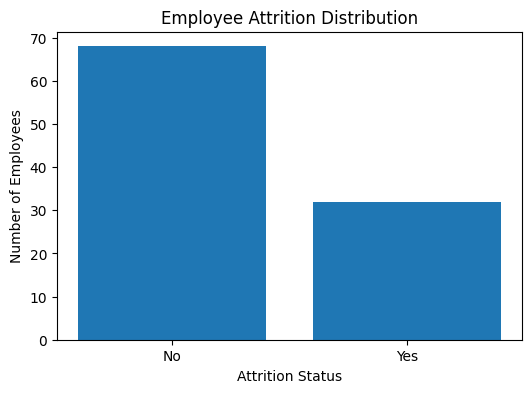

In [6]:
attrition_counts = df["Attrition_Status"].value_counts()

plt.figure(figsize=(6, 4))
plt.bar(attrition_counts.index, attrition_counts.values)

plt.title("Employee Attrition Distribution")
plt.xlabel("Attrition Status")
plt.ylabel("Number of Employees")

plt.show()

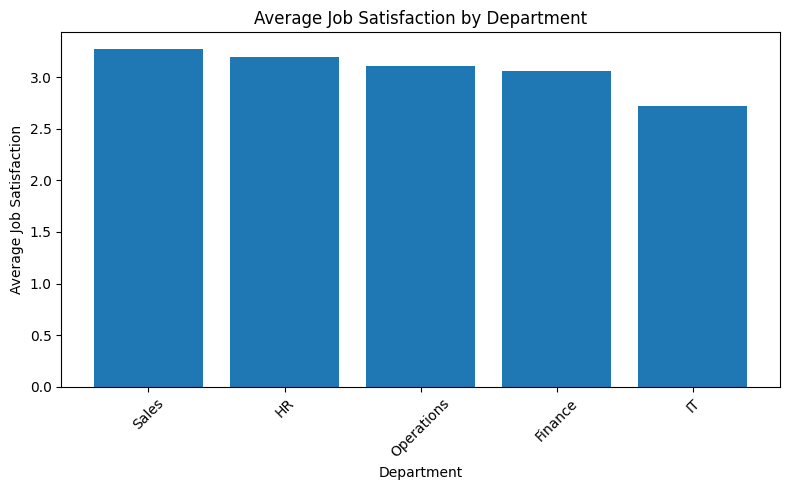

In [7]:
avg_satisfaction = (
    df.groupby("Department")["Job_Satisfaction"]
    .mean()
    .sort_values(ascending=False)
)

plt.figure(figsize=(8, 5))
plt.bar(avg_satisfaction.index, avg_satisfaction.values)

plt.title("Average Job Satisfaction by Department")
plt.xlabel("Department")
plt.ylabel("Average Job Satisfaction")

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [8]:
model_data = df.copy()

department_encoder = LabelEncoder()
attrition_encoder = LabelEncoder()

model_data["Department"] = department_encoder.fit_transform(
    model_data["Department"]
)

model_data["Attrition_Status"] = attrition_encoder.fit_transform(
    model_data["Attrition_Status"]
)

X = model_data.drop(
    columns=["Employee_ID", "Attrition_Status"]
)

y = model_data["Attrition_Status"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training samples:", X_train.shape[0])
print("Testing samples:", X_test.shape[0])
print("Data prepared successfully!")

Training samples: 80
Testing samples: 20
Data prepared successfully!


In [9]:
model = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)

accuracy = accuracy_score(y_test, y_pred)

print("Random Forest Model Trained Successfully!")
print(f"Model Accuracy: {accuracy * 100:.2f}%")

print("\nClassification Report:")
print(classification_report(
    y_test,
    y_pred,
    zero_division=0
))

Random Forest Model Trained Successfully!
Model Accuracy: 60.00%

Classification Report:
              precision    recall  f1-score   support

           0       0.67      0.86      0.75        14
           1       0.00      0.00      0.00         6

    accuracy                           0.60        20
   macro avg       0.33      0.43      0.38        20
weighted avg       0.47      0.60      0.53        20



Feature Importance:


,Feature,Importance
6,Training_Hours,0.195086
3,Monthly_Income,0.182926
1,Age,0.167857
2,Years_at_Company,0.163500
5,Performance_Rating,0.100548
4,Job_Satisfaction,0.099438
0,Department,0.090644


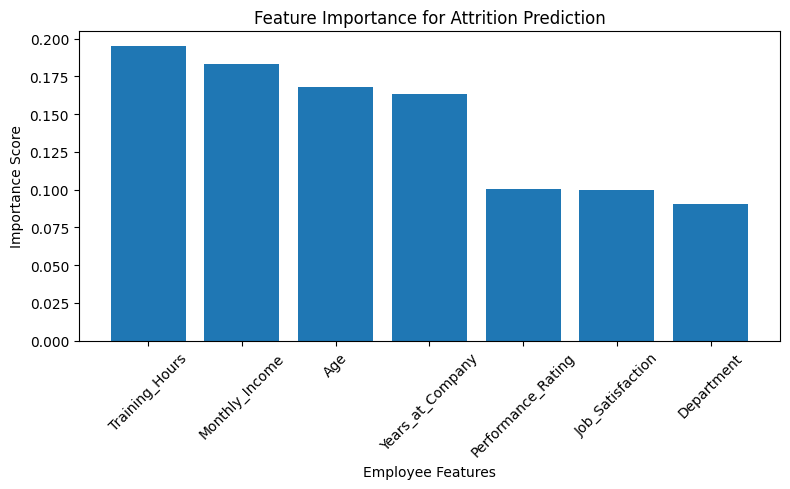

In [10]:
feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": model.feature_importances_
}).sort_values(
    by="Importance",
    ascending=False
)

print("Feature Importance:")
display(feature_importance)

plt.figure(figsize=(8, 5))
plt.bar(
    feature_importance["Feature"],
    feature_importance["Importance"]
)

plt.title("Feature Importance for Attrition Prediction")
plt.xlabel("Employee Features")
plt.ylabel("Importance Score")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()